In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from epimodels.continuous.models import SISLogistic
from epimodels.fitting import (
    Dataset,
    DataSeries,
    ParameterSpec,
    ModelFitter,
    FittingResult,
    fit_model,
    SumOfSquaredErrors,
    WeightedSSE,
    PoissonLikelihood,
    NegativeBinomialLikelihood,
    NormalLikelihood,
    HuberLoss,
    ScipyOptimizer,
    MultiStartOptimizer,
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
TRUE_BETA = 0.5
TRUE_GAMMA = 0.2
TRUE_R = 0.1
TRUE_K = 10000

INITIAL_INFECTED = 100
INITIAL_SUSCEPTIBLE = 5000

sis_model = SISLogistic()
sis_model(
    inits=[INITIAL_SUSCEPTIBLE, INITIAL_INFECTED],
    trange=[0, 100],
    totpop=INITIAL_SUSCEPTIBLE + INITIAL_INFECTED, 
    params={"beta": TRUE_BETA, "gamma": TRUE_GAMMA, "r": TRUE_R, "k": TRUE_K,
    },
)

times = sis_model.traces["time"]
true_S = sis_model.traces["S"]
true_I = sis_model.traces["I"]

print("True parameters:")
print(f"beta={TRUE_BETA}, gamma={TRUE_GAMMA}, r={TRUE_R}, k={TRUE_K}")
print(f"R0 = {TRUE_BETA / TRUE_GAMMA:.2f}")

True parameters:
beta=0.5, gamma=0.2, r=0.1, k=10000
R0 = 2.50


In [3]:
observed_S = np.random.poisson(lam=true_S).astype(float)
observed_I = np.random.poisson(lam=true_I).astype(float)

observed_S = np.maximum(observed_S, 0)
observed_I = np.maximum(observed_I, 0)

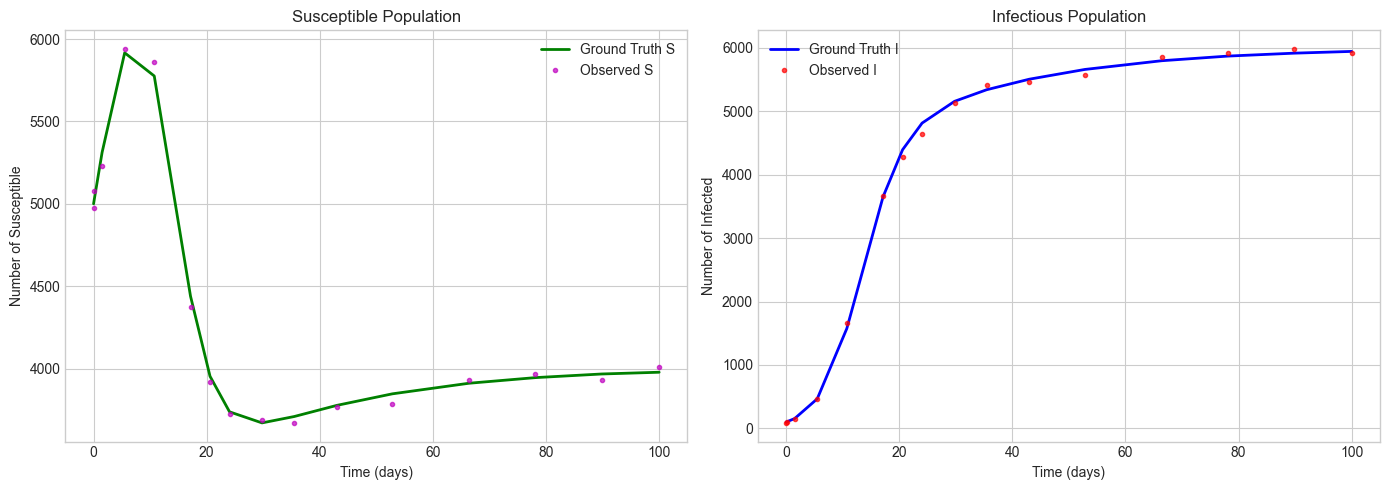

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(times, true_S, 'g-', label='Ground Truth S', linewidth=2)
axes[0].plot(times, observed_S, 'mo', label='Observed S', markersize=3, alpha=0.7)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Number of Susceptible')
axes[0].set_title('Susceptible Population')
axes[0].legend()

axes[1].plot(times, true_I, 'b-', label='Ground Truth I', linewidth=2)
axes[1].plot(times, observed_I, 'ro', label='Observed I', markersize=3, alpha=0.7)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Number of Infected')
axes[1].set_title('Infectious Population')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
model = SISLogistic()

dataset = Dataset(model)

dataset.register(
    name='infected',
    values=observed_I,
    times=times,
    state_variable='I',
    time_unit='days',
)

validation_result = dataset.validate(total_population=INITIAL_SUSCEPTIBLE + INITIAL_INFECTED)
print(f"Dataset valid: {validation_result.is_valid}")
print(f"Time range: {dataset.time_range}")
print(dataset)

Dataset valid: True
Time range: (0.0, 100.0)
Dataset(n_series=1, variables=['I'], time_range=(0.0, 100.0))


In [6]:
param_specs = [
    ParameterSpec(
        name='beta',
        bounds=(0.1, 1.0),
        initial=0.7,
    ),
    ParameterSpec(
        name='gamma',
        bounds=(0.01, 0.5),
        initial=0.3,
    ),
    ParameterSpec(
        name='r',
        bounds=(0.01, 0.5),
        initial=0.4,
    ),
    ParameterSpec(
        name='k',
        bounds=(1000, 20000),
        initial=5000,
    ),
]

print("Parameters to fit:")
for spec in param_specs:
    print(f"  {spec.name}: bounds={spec.bounds}, initial={spec.initial}")

Parameters to fit:
  beta: bounds=(0.1, 1.0), initial=0.7
  gamma: bounds=(0.01, 0.5), initial=0.3
  r: bounds=(0.01, 0.5), initial=0.4
  k: bounds=(1000, 20000), initial=5000


In [7]:
fitter = ModelFitter(
    model=model,
    dataset=dataset,
    parameters_to_fit=param_specs,
    total_population=INITIAL_SUSCEPTIBLE + INITIAL_INFECTED,
    optimizer=ScipyOptimizer(method='L-BFGS-B', max_iterations=200),
)

result = fitter.fit()

print("\n" + "="*50)
print("FITTING RESULTS")
print("="*50)
print(f"Convergence: {result.convergence}")
print(f"Number of evaluations: {result.n_evaluations}")
print(f"Final loss: {result.best_loss:.2f}")

print("\nFitted parameters:")

true_values = {
    "beta": TRUE_BETA,
    "gamma": TRUE_GAMMA,
    "r": TRUE_R,
    "k": TRUE_K,
}

for param, value in result.best_params.items():
    true_val = true_values[param]
    error = abs(value - true_val) / true_val * 100

    print(f"  {param}: {value:.4f} (true: {true_val}, error: {error:.1f}%)")

C:\Users\darla\epimodels\epimodels\fitting\base.py:200: UserWarning: Series 'infected': values exceed total population
  warnings.warn(warning, UserWarning)



FITTING RESULTS
Convergence: True
Number of evaluations: 330
Final loss: 45545.77

Fitted parameters:
  beta: 0.6176 (true: 0.5, error: 23.5%)
  gamma: 0.2948 (true: 0.2, error: 47.4%)
  r: 0.1048 (true: 0.1, error: 4.8%)
  k: 11449.9407 (true: 10000, error: 14.5%)


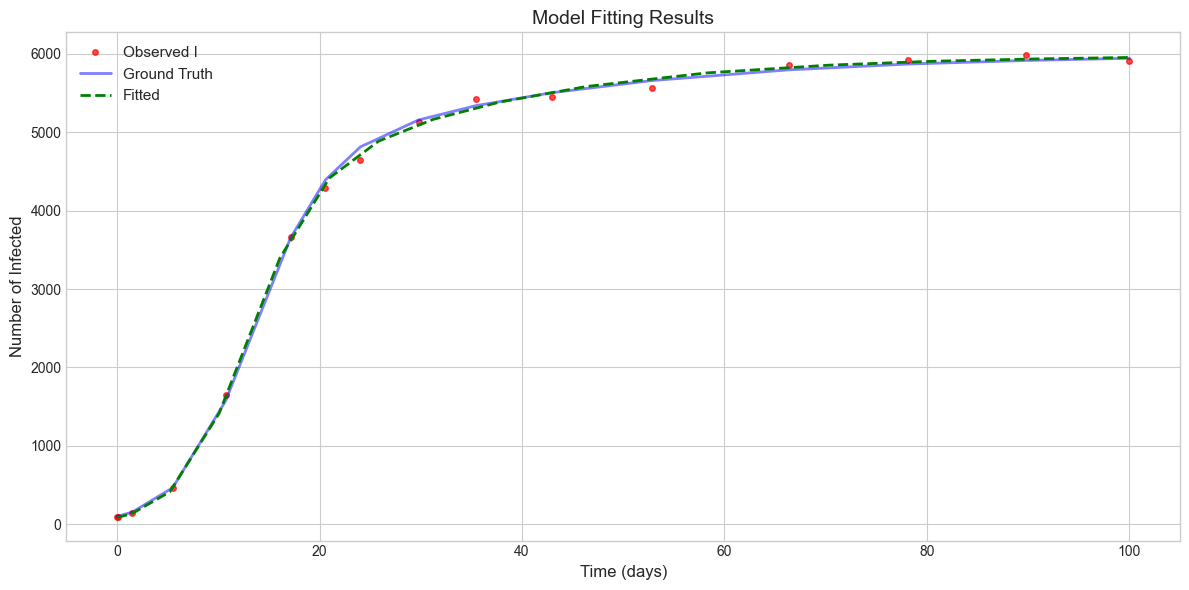

In [18]:
fitted_model = result.fitted_model

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(times, observed_I, 'ro', label='Observed I', markersize=4, alpha=0.7)

ax.plot(times, true_I, 'b-', label='Ground Truth', linewidth=2, alpha=0.5)

if fitted_model is not None and fitted_model.traces:
    ax.plot(fitted_model.traces['time'], fitted_model.traces['I'], 
            'g--', label='Fitted', linewidth=2)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Number of Infected', fontsize=12)
ax.set_title('Model Fitting Results', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [20]:
model2 = SISLogistic()
dataset2 = Dataset(model2)

dataset2.register(
    name='susceptible',
    values=observed_S,
    times=times,
    state_variable='S',
).register(
    name='infected',
    values=observed_I,
    times=times,
    state_variable='I',
)

print(f"Registered series: {list(dataset2.series.keys())}")
print(f"State variables mapped: {list(set(s.state_variable for s in dataset2.series.values()))}")

Registered series: ['susceptible', 'infected']
State variables mapped: ['S', 'I']


In [21]:
from epimodels.fitting import DataValidationError

model_test = SISLogistic()
dataset_test = Dataset(model_test)

dataset_test.register(
    name='invalid',
    values=observed_I,
    times=times,
    state_variable='X',
)

validation = dataset_test.validate()
print(f"Valid: {validation.is_valid}")
print(f"Errors: {validation.errors}")

Valid: False
Errors: ["Series 'invalid': state variable 'X' not found in model. Available: ['S', 'I']", "Data mapped to non-existent variables: ['X']"]


In [22]:
model3 = SISLogistic()
dataset3 = Dataset(model3)

weeks = times / 7.0

dataset3.register(
    name='infected_weekly',
    values=observed_I,
    times=weeks,
    state_variable='I',
    time_unit='weeks',
)

print(f"Dataset time unit: {dataset3.time_unit}")
print(f"Series time unit: {dataset3.series['infected_weekly'].time_unit}")
print(f"Time range: {dataset3.time_range}")

Dataset time unit: weeks
Series time unit: weeks
Time range: (0.0, 14.285714285714286)


In [23]:
import pandas as pd

df = pd.DataFrame({
    'day': times,
    'susceptible': observed_S,
    'infected': observed_I,
})

print("Sample data:")
display(df.head(10))

model_df = SISLogistic()
dataset_df = Dataset(model_df)

dataset_df.register_from_dataframe(
    df=df,
    time_column='day',
    mapping={'susceptible': 'S', 'infected': 'I'},
    time_unit='days',
)

print(f"\nRegistered from DataFrame: {list(dataset_df.series.keys())}")

Sample data:


,day,susceptible,infected
0,0.000000,4974.0,86.0
1,0.136966,5079.0,96.0
2,1.506630,5228.0,147.0
3,5.500993,5939.0,468.0
4,10.728546,5859.0,1654.0
5,17.141654,4371.0,3670.0
6,20.590730,3917.0,4286.0
7,24.039805,3726.0,4647.0
8,29.779266,3690.0,5134.0
9,35.469539,3672.0,5419.0



Registered from DataFrame: ['susceptible', 'infected']


In [8]:
loss_functions = {
    'SSE': SumOfSquaredErrors(),
    'Poisson': PoissonLikelihood(),
    'NegBinom': NegativeBinomialLikelihood(dispersion=5.0),
    'Normal': NormalLikelihood(),
    'Huber': HuberLoss(delta=10.0),
}

print("Available loss functions:")
for name, lf in loss_functions.items():
    print(f"  - {name}: {lf.__class__.__name__}")

Available loss functions:
  - SSE: SumOfSquaredErrors
  - Poisson: PoissonLikelihood
  - NegBinom: NegativeBinomialLikelihood
  - Normal: NormalLikelihood
  - Huber: HuberLoss


In [9]:
results_comparison = {}

for name, loss_fn in loss_functions.items():
    print(f"Fitting with {name}...")
    
    fitter_comp = ModelFitter(
        model=SISLogistic(),
        dataset=dataset,
        parameters_to_fit=param_specs,
        total_population=INITIAL_SUSCEPTIBLE + INITIAL_INFECTED,
        loss_fn=loss_fn,
        optimizer=ScipyOptimizer(method='L-BFGS-B', max_iterations=100),
    )
    
    result = fitter_comp.fit()
    results_comparison[name] = result

Fitting with SSE...
Fitting with Poisson...
Fitting with NegBinom...
Fitting with Normal...
Fitting with Huber...


In [10]:
print("\n" + "="*90)
print("LOSS FUNCTION COMPARISON (SIS Logistic)")
print("="*90)

print(f"{'Loss':<12} {'beta':>8} {'gamma':>8} {'r':>8} {'k':>10} {'R0':>8} {'LossVal':>12}")
print("-"*90)

print(f"{'TRUE':<12} {TRUE_BETA:>8.3f} {TRUE_GAMMA:>8.3f} {TRUE_R:>8.3f} {TRUE_K:>10.0f} {TRUE_BETA/TRUE_GAMMA:>8.2f} {'-':>12}")
print("-"*90)

for name, result in results_comparison.items():
    beta = result.best_params['beta']
    gamma = result.best_params['gamma']
    r = result.best_params['r']
    k = result.best_params['k']
    r0 = beta / gamma

    print(f"{name:<12} {beta:>8.3f} {gamma:>8.3f} {r:>8.3f} {k:>10.0f} {r0:>8.2f} {result.best_loss:>12.2f}")


LOSS FUNCTION COMPARISON (SIS Logistic)
Loss             beta    gamma        r          k       R0      LossVal
------------------------------------------------------------------------------------------
TRUE            0.500    0.200    0.100      10000     2.50            -
------------------------------------------------------------------------------------------
SSE             0.618    0.295    0.105      11450     2.10     45545.77
Poisson         0.391    0.083    0.034      10939     4.69       193.59
NegBinom        0.434    0.111    0.406       5000     3.92       256.63
Normal          0.336    0.010    0.010       5000    33.59       124.37
Huber           0.311    0.010    0.010       5022    31.12     62016.12


In [12]:
scipy_methods = ['L-BFGS-B', 'Nelder-Mead', 'Powell', 'differential_evolution']
optimizer_results = {}

for method in scipy_methods:
    print(f"Testing {method}...")
    
    optimizer = ScipyOptimizer(method=method, max_iterations=100)
    
    fitter_opt = ModelFitter(
        model=SISLogistic(),
        dataset=dataset,
        parameters_to_fit=param_specs,
        total_population=INITIAL_SUSCEPTIBLE + INITIAL_INFECTED,
        optimizer=optimizer,
    )
    
    result = fitter_opt.fit()
    optimizer_results[method] = result

Testing L-BFGS-B...
Testing Nelder-Mead...
Testing Powell...
Testing differential_evolution...


In [13]:
print("\n" + "="*100)
print("OPTIMIZER COMPARISON (SIS Logistic)")
print("="*100)

print(f"{'Method':<25} {'beta':>8} {'gamma':>8} {'r':>8} {'k':>10} {'R0':>8} {'Evals':>8} {'Conv':>8}")
print("-"*100)

for method, result in optimizer_results.items():
    beta = result.best_params['beta']
    gamma = result.best_params['gamma']
    r = result.best_params['r']
    k = result.best_params['k']
    r0 = beta / gamma

    print(f"{method:<25} {beta:>8.3f} {gamma:>8.3f} {r:>8.3f} {k:>10.0f} {r0:>8.2f} {result.n_evaluations:>8} {str(result.convergence):>8}")


OPTIMIZER COMPARISON (SIS Logistic)
Method                        beta    gamma        r          k       R0    Evals     Conv
----------------------------------------------------------------------------------------------------
L-BFGS-B                     0.618    0.295    0.105      11450     2.10      330     True
Nelder-Mead                  0.618    0.295    0.105      11450     2.10      330     True
Powell                       0.618    0.295    0.105      11450     2.10      330     True
differential_evolution       0.608    0.286    0.104      11315     2.13     6105    False


In [17]:
base_optimizer = ScipyOptimizer(method='L-BFGS-B', max_iterations=50)

multi_start = MultiStartOptimizer(
    base_optimizer=base_optimizer,
    n_starts=5,
    sampling_method='latin_hypercube',
    seed=42,
)

fitter_ms = ModelFitter(
    model=SISLogistic(),
    dataset=dataset,
    parameters_to_fit=param_specs,
    total_population=INITIAL_SUSCEPTIBLE + INITIAL_INFECTED,
    optimizer=multi_start,
)

result_ms = fitter_ms.fit()

print(f"Multi-start optimization results:")

print(f"  beta: {result_ms.best_params['beta']:.4f}")
print(f"  gamma: {result_ms.best_params['gamma']:.4f}")
print(f"  r: {result_ms.best_params['r']:.4f}")
print(f"  k: {result_ms.best_params['k']:.0f}")

print(f"  Total evaluations: {result_ms.n_evaluations}")
print(f"  Converged: {result_ms.convergence}")

Multi-start optimization results:
  beta: 0.6176
  gamma: 0.2948
  r: 0.1048
  k: 11450
  Total evaluations: 1440
  Converged: True


In [21]:
fitter_fixed = ModelFitter(
    model=SISLogistic(),
    dataset=dataset,
    parameters_to_fit=[
        ParameterSpec(name='beta', bounds=(0.1, 1.0), initial=0.7),
        ParameterSpec(name='gamma',bounds=(0.01, 0.5), initial=0.3)
    ],
    total_population=INITIAL_SUSCEPTIBLE + INITIAL_INFECTED,
    fixed_params={'r': TRUE_R, 'k': TRUE_K},  
)

result_fixed = fitter_fixed.fit()

print("Fitting with fixed gamma:")
print(f"  Fitted beta: {result_fixed.best_params['beta']:.4f} (true: {TRUE_BETA})")
print(f"  Fitted gamma: {result_fixed.best_params['gamma']:.4f} (true: {TRUE_GAMMA})")
print(f"  Fixed r: {TRUE_R}")
print(f"  Fixed k: {TRUE_K}")

Fitting with fixed gamma:
  Fitted beta: 0.5215 (true: 0.5)
  Fitted gamma: 0.2090 (true: 0.2)
  Fixed r: 0.1
  Fixed k: 10000


C:\Users\darla\epimodels\epimodels\fitting\base.py:200: UserWarning: Series 'infected': values exceed total population
  warnings.warn(warning, UserWarning)


In [27]:
param_specs_log = [
    ParameterSpec(
        name='beta',
        bounds=(0.01, 1.0),
        initial=0.3,
        log_scale=True,
    ),
    ParameterSpec(
        name='gamma',
        bounds=(0.01, 0.5),
        initial=0.1,
        log_scale=True,
    ),
    ParameterSpec(
        name='r',
        bounds=(0.01, 0.5),
        initial=0.05,
        log_scale=True,
    ),
    ParameterSpec(
        name='k',
        bounds=(1000, 20000),
        initial=8000,
        log_scale=True,
    ),
]

print("Log-scale parameter specs:")
for spec in param_specs_log:
    print(f"  {spec.name}: bounds={spec.bounds}, log_scale={spec.log_scale}")

Log-scale parameter specs:
  beta: bounds=(0.01, 1.0), log_scale=True
  gamma: bounds=(0.01, 0.5), log_scale=True
  r: bounds=(0.01, 0.5), log_scale=True
  k: bounds=(1000, 20000), log_scale=True


In [30]:
profile_result = fitter.profile_likelihood(
    param_name='gamma',
    n_points=20,
    threshold=3.84,
)

print("Profile likelihood analysis for gamma:")
print(f"  Minimum loss: {profile_result['min_loss']:.2f}")
print(f"  95% CI threshold: {profile_result['threshold_loss']:.2f}")
print(f"  Confidence interval: {profile_result['confidence_interval']}")

Profile likelihood analysis for gamma:
  Minimum loss: 45528.81
  95% CI threshold: 45530.73
  Confidence interval: (np.float64(0.29368421052631577), np.float64(0.29368421052631577))


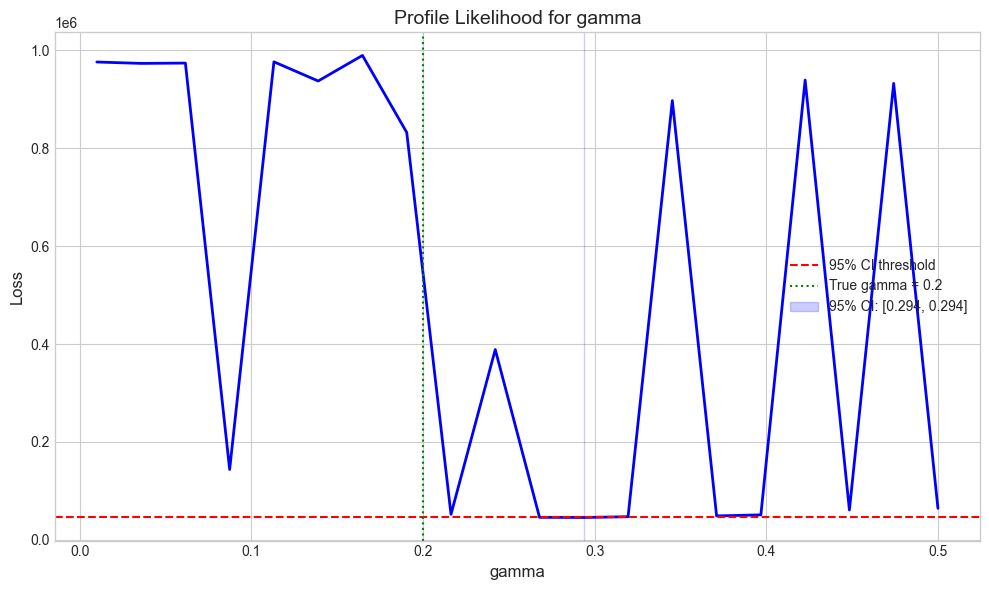

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(profile_result['values'], profile_result['losses'], 'b-', linewidth=2)
ax.axhline(y=profile_result['threshold_loss'], color='r', linestyle='--', 
           label=f"95% CI threshold")
ax.axvline(x=TRUE_GAMMA, color='g', linestyle=':', label=f"True gamma = {TRUE_GAMMA}")

ci = profile_result['confidence_interval']
if ci[0] is not None and ci[1] is not None:
    ax.axvspan(ci[0], ci[1], alpha=0.2, color='blue', label=f"95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")

ax.set_xlabel('gamma', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Profile Likelihood for gamma', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()